In [4]:
!pip install ultralytics

In [8]:
!cat /kaggle/working/data.yaml



path: /kaggle/input/datasets/vyaptishah/datatask01

train: images
val: images

nc: 1

names: ['plate']


In [12]:
import os

label_dir = "/kaggle/input/datasets/vyaptishah/datatask01/dataset01/labels"
new_label_dir = "/kaggle/working/labels"
os.makedirs(new_label_dir, exist_ok=True)

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file), "r") as f:
        lines = f.readlines()

    new_lines = []

    for line in lines:
        parts = line.strip().split()
        class_id = parts[0]
        coords = list(map(float, parts[1:]))

        xs = coords[0::2]
        ys = coords[1::2]

        x_center = (min(xs) + max(xs)) / 2
        y_center = (min(ys) + max(ys)) / 2
        width = max(xs) - min(xs)
        height = max(ys) - min(ys)

        new_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

    with open(os.path.join(new_label_dir, file), "w") as f:
        f.write("\n".join(new_lines))

print("Conversion completed")


Conversion completed


In [13]:
!cp -r /kaggle/input/datasets/vyaptishah/datatask01/dataset01/images /kaggle/working/images


In [14]:
with open("/kaggle/working/data.yaml", "w") as f:
    f.write("""
path: /kaggle/working

train: images
val: images

nc: 23

names: ['0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22']
""")


In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ae01a37c080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042, 

In [16]:
metrics = model.val(data="/kaggle/working/data.yaml")

print(metrics)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,133 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 427.1±265.5 MB/s, size: 10.5 KB)
val: Scanning /kaggle/working/labels.cache... 321 images, 0 backgrounds, 181 corrupt: 100% ━━━━━━━━━━━━ 321/321 112.2Mit/s 0.0s
train: /kaggle/working/images/019c29b7-20260108_MH03OU6316_plate_1.jpg: ignoring corrupt image/label: Label class 30 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/02a1bad0-20260108_MH02EP6154_plate_1.jpg: ignoring corrupt image/label: Label class 25 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/03748753-20260108_MH03AW3197_plate_1.jpg: ignoring corrupt image/label: Label class 32 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/04d7848f-20260108_MH01EW8851_plate_1.jpg: ignoring corrup

In [17]:
#test on images
results = model.predict(
    source="/kaggle/working/images",
    save=True,
    conf=0.25
)


image 1/321 /kaggle/working/images/00dd5ff0-20260108_MH01OB2998_plate_1.jpg: 192x640 1 0, 1 1, 1 2, 1 8, 2 9s, 1 11, 1 13, 1 17, 1 22, 43.0ms
image 2/321 /kaggle/working/images/014f630b-20260108_MH02EK5651_plate_1.jpg: 192x640 1 0, 1 1, 1 2, 2 5s, 1 6, 1 14, 1 17, 1 20, 1 22, 5.3ms
image 3/321 /kaggle/working/images/019c29b7-20260108_MH03OU6316_plate_1.jpg: 192x640 1 0, 1 1, 2 3s, 2 6s, 2 13s, 1 17, 1 22, 5.5ms
image 4/321 /kaggle/working/images/02a1bad0-20260108_MH02EP6154_plate_1.jpg: 160x640 1 0, 1 1, 1 2, 1 4, 2 5s, 1 6, 1 14, 1 17, 1 22, 38.0ms
image 5/321 /kaggle/working/images/0320d927-20260108_MH02EK1494_plate_1.jpg: 192x640 1 0, 1 1, 1 2, 2 4s, 1 9, 1 14, 1 17, 1 20, 1 22, 6.0ms
image 6/321 /kaggle/working/images/03748753-20260108_MH03AW3197_plate_1.jpg: 192x640 1 0, 1 1, 2 3s, 1 4, 2 7s, 1 9, 2 17s, 2 22s, 5.2ms
image 7/321 /kaggle/working/images/04d7848f-20260108_MH01EW8851_plate_1.jpg: 192x640 1 0, 2 1s, 1 5, 2 8s, 1 14, 2 17s, 2 22s, 5.3ms
image 8/321 /kaggle/working/imag

In [18]:
#test on single image
model.predict(
    source="/kaggle/working/images/15183288-20260108_MH01EY6882_plate_1.jpg",
    save=True,
    conf=0.25
)


image 1/1 /kaggle/working/images/15183288-20260108_MH01EY6882_plate_1.jpg: 192x640 1 0, 2 1s, 1 2, 1 6, 2 8s, 1 14, 1 17, 1 20, 1 22, 7.5ms
Speed: 1.0ms preprocess, 7.5ms inference, 1.7ms postprocess per image at shape (1, 3, 192, 640)
Results saved to /kaggle/working/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '10', 11: '11', 12: '12', 13: '13', 14: '14', 15: '15', 16: '16', 17: '17', 18: '18', 19: '19', 20: '20', 21: '21', 22: '22'}
 obb: None
 orig_img: array([[[23, 23, 23],
         [22, 22, 22],
         [24, 24, 24],
         ...,
         [25, 25, 25],
         [16, 16, 16],
         [17, 17, 17]],
 
        [[28, 28, 28],
         [25, 25, 25],
         [23, 23, 23],
         ...,
         [17, 17, 17],
         [16, 16, 16],
         [18, 18, 18]],
 
        [[27, 27, 27],
         [26, 26, 26],
         [27, 27, 27],
         ...,
         [21, 21, 21],
         [15, 15, 15],
         [20, 20, 20]],
 
        ...,
 
        [[31, 31, 31],
         [31, 31, 31],
         [30, 30, 30],
         ...,
         [17, 17, 17],
         [13, 13, 13],
         [1

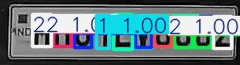

In [19]:
#Show predicted image inside Kaggle
from IPython.display import Image

Image("/kaggle/working/runs/detect/predict/15183288-20260108_MH01EY6882_plate_1.jpg")


In [20]:
#get confusion matrix
metrics = model.val(data="/kaggle/working/data.yaml", plots=True)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 357.6±170.2 MB/s, size: 8.9 KB)
val: Scanning /kaggle/working/labels.cache... 321 images, 0 backgrounds, 181 corrupt: 100% ━━━━━━━━━━━━ 321/321 122.4Mit/s 0.0s
train: /kaggle/working/images/019c29b7-20260108_MH03OU6316_plate_1.jpg: ignoring corrupt image/label: Label class 30 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/02a1bad0-20260108_MH02EP6154_plate_1.jpg: ignoring corrupt image/label: Label class 25 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/03748753-20260108_MH03AW3197_plate_1.jpg: ignoring corrupt image/label: Label class 32 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/04d7848f-20260108_MH01EW8851_plate_1.jpg: ignoring corrupt image/label: Label class 32 exceeds dataset class count 23. Possible class labe

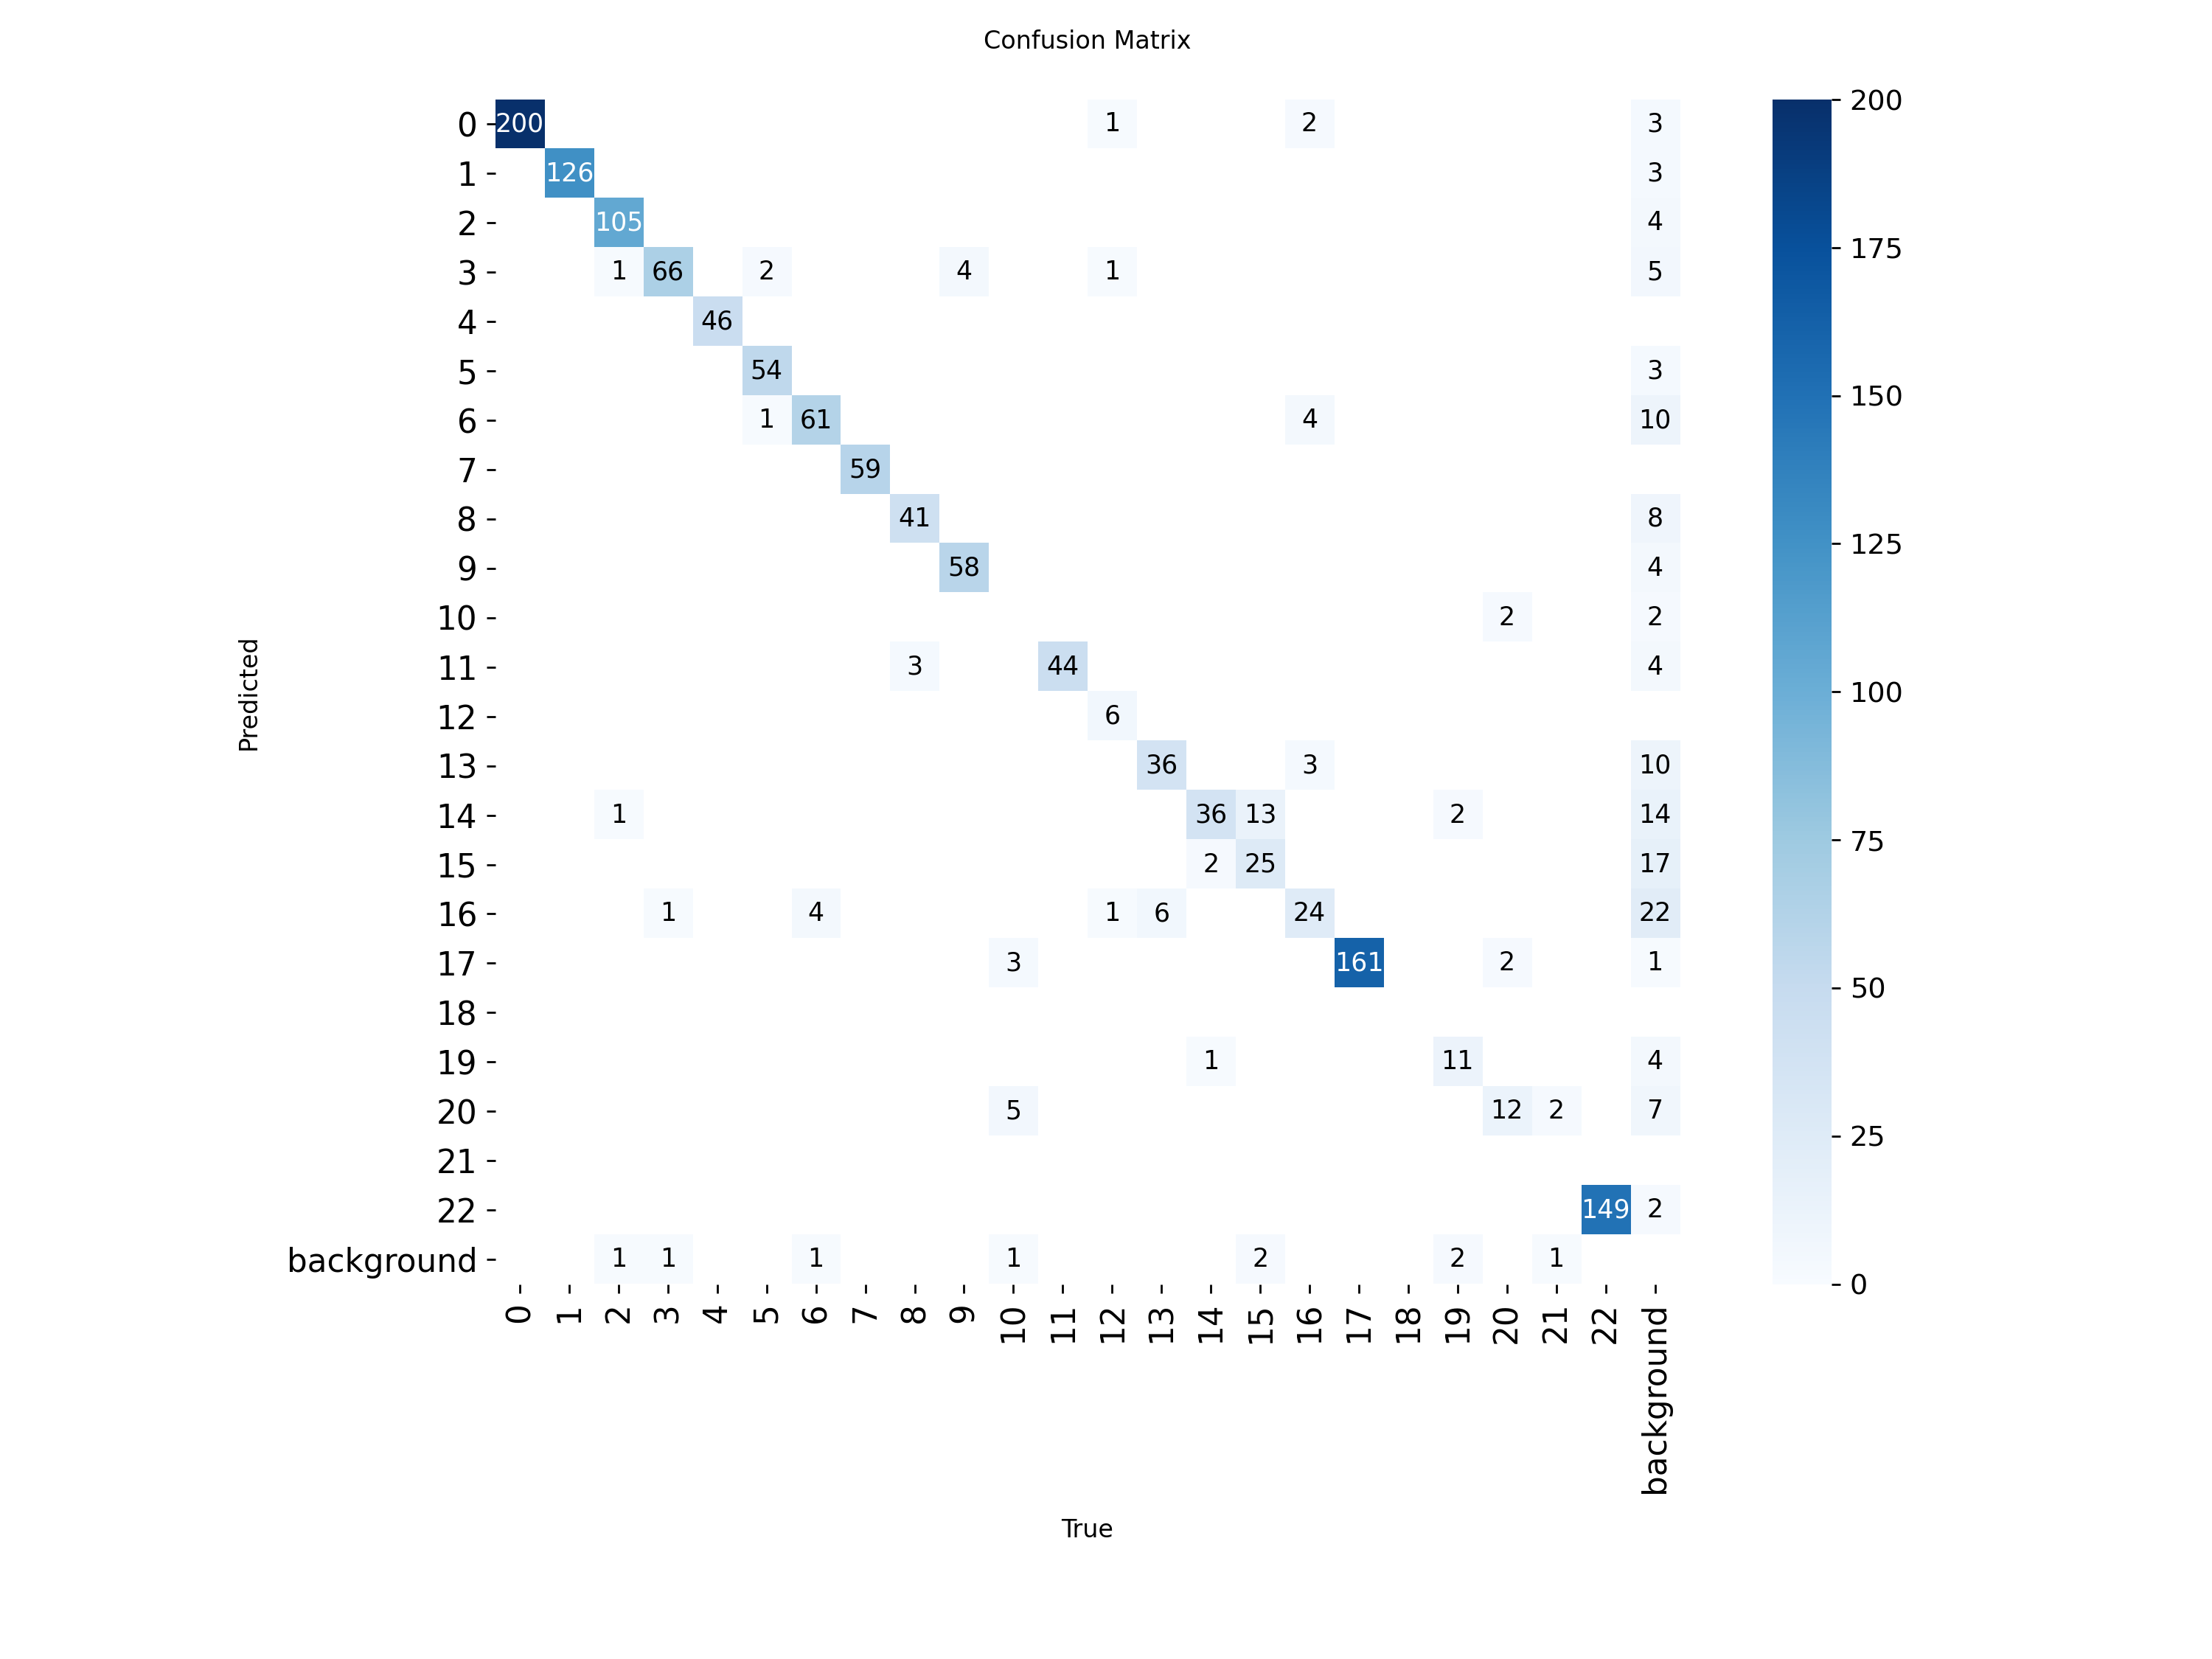

In [27]:
from IPython.display import Image
Image("/kaggle/working/runs/detect/val/confusion_matrix.png")


In [28]:
metrics = model.val(data="/kaggle/working/data.yaml")

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 353.7±172.1 MB/s, size: 9.3 KB)
val: Scanning /kaggle/working/labels.cache... 321 images, 0 backgrounds, 181 corrupt: 100% ━━━━━━━━━━━━ 321/321 56.1Mit/s 0.0s
train: /kaggle/working/images/019c29b7-20260108_MH03OU6316_plate_1.jpg: ignoring corrupt image/label: Label class 30 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/02a1bad0-20260108_MH02EP6154_plate_1.jpg: ignoring corrupt image/label: Label class 25 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/03748753-20260108_MH03AW3197_plate_1.jpg: ignoring corrupt image/label: Label class 32 exceeds dataset class count 23. Possible class labels are 0-22
train: /kaggle/working/images/04d7848f-20260108_MH01EW8851_plate_1.jpg: ignoring corrupt image/label: Label class 32 exceeds dataset class count 23. Possible class label